# Assignment M9: Discriminant Analysis & Naive Bayes
**George Khramtchenko - University of Connecticut**

-------------------------------------
The work contained and presented here is my work and my work alone. The following sources were used:
*   KhramtchenkoGeorgeOPIM5604AssignmentM8.ipynb
*   OPIM 5604 Module 9 DA and Naive Bayes Models.ipynb
*   Google Gemini


# Environment Setup

In [1]:
# import modules

import pandas as pd # for data viz and wrangling
import numpy as np # for 'numeric python'
import matplotlib.pyplot as plt # for data viz (more complex than pylab)
import seaborn as sns
from pylab import * # for data viz (import * means 'import all of the functions')

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn import metrics
from scipy import stats
import statsmodels.api as sm

In [2]:
# Mount my google drive for access
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Prompt 1:** Read in the Telco dataset and determine how many rows and columns it has.

In [41]:
# Initially, an encoding error prevented the code from running due to an issue with reading the encoding. Encoding handling was added for 'latin-1'.
try:
    df = pd.read_csv('/content/drive/MyDrive/UConn/OPIM-5604-Predictive-Modeling/Modules/Module 9/Assignment M9/Telco_customer_churn.csv', encoding='latin-1')
    # Obtain the number of rows and columns this data has
    print(df.shape)

except UnicodeDecodeError:
    print("UnicodeDecodeError: Failed to decode the file using 'latin-1' encoding.")

(7043, 18)


**Answer:** This dataset has **7,043** rows and **18** columns.

**Prompt 2:** Partition the data into a 60/20/20 split.

We have a mix of categorical and continuous predictors. I'll change the target variable to 1s and 0s.

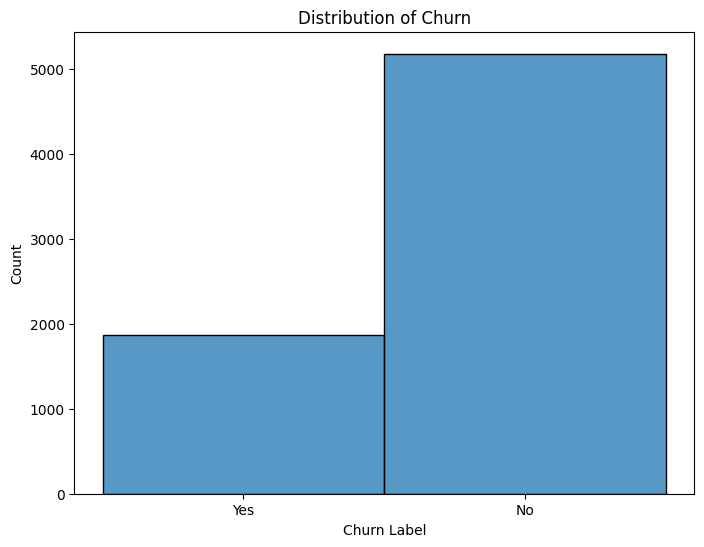


Counts of Churn Label
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


In [42]:
# Show a histogram of 'Churn Label' counts
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='Churn Label', bins=2) # bins=2 for two categories (0 and 1)
plt.title('Distribution of Churn')
plt.xlabel('Churn Label')
plt.ylabel('Count')
plt.xticks([0, 1]) # Set x-axis ticks at 0 and 1
plt.show()

# Display counts
churn_counts = df['Churn Label'].value_counts()
print("\nCounts of Churn Label")
print(churn_counts)

In [43]:
# Convert 'Churn Label' to numerical (Yes=1, No=0) using map
df['Churn Value'] = df['Churn Label'].map({'Yes': 1, 'No': 0})

# Display the first few rows and unique values to see the changes in the target variable
print(df.head())
print("\nUnique values after conversion:")
print(df['Churn Label'].unique())

   CustomerID  Gender Senior Citizen Partner Dependents  Tenure Months  \
0  3668-QPYBK    Male             No      No         No              2   
1  9237-HQITU  Female             No      No        Yes              2   
2  9305-CDSKC  Female             No      No        Yes              8   
3  7892-POOKP  Female             No     Yes        Yes             28   
4  0280-XJGEX    Male             No      No        Yes             49   

  Multiple Lines Internet Service Online Security Online Backup  \
0             No              DSL             Yes           Yes   
1             No      Fiber optic              No            No   
2            Yes      Fiber optic              No            No   
3            Yes      Fiber optic              No            No   
4            Yes      Fiber optic              No           Yes   

  Device Protection Tech Support        Contract Paperless Billing  \
0                No           No  Month-to-month               Yes   
1           

Drop CustomerID because it has too many categories and is irrelevant to this assignment.

In [44]:
# Drop the 'CustomerID' column
df = df.drop('CustomerID', axis=1)

Show a bar plot of the contract types to see if it can be used for dummy variables.

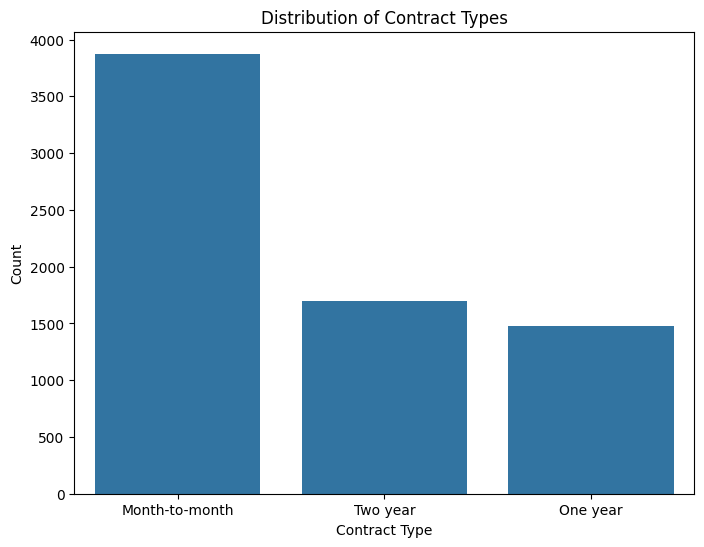


Counts of Contract Levels:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

Percentages of Contract Levels:
Contract
Month-to-month    55.019168
Two year          24.066449
One year          20.914383
Name: proportion, dtype: float64


In [45]:
# Show a histogram/bar plot of 'Contract' with counts
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Contract')
plt.title('Distribution of Contract Types')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

# Display counts and percentages
contract_counts = df['Contract'].value_counts()
contract_percentages = df['Contract'].value_counts(normalize=True) * 100

print("\nCounts of Contract Levels:")
print(contract_counts)

print("\nPercentages of Contract Levels:")
print(contract_percentages)

Create dummy variable(s) before building the discriminant analysis model.

In [46]:
# Create dummy variables for 'Contract'
df = pd.get_dummies(df, columns=['Contract'], drop_first=True)

# Display the first few rows to see the changes
print(df.head())

   Gender Senior Citizen Partner Dependents  Tenure Months Multiple Lines  \
0    Male             No      No         No              2             No   
1  Female             No      No        Yes              2             No   
2  Female             No      No        Yes              8            Yes   
3  Female             No     Yes        Yes             28            Yes   
4    Male             No      No        Yes             49            Yes   

  Internet Service Online Security Online Backup Device Protection  \
0              DSL             Yes           Yes                No   
1      Fiber optic              No            No                No   
2      Fiber optic              No            No               Yes   
3      Fiber optic              No            No               Yes   
4      Fiber optic              No           Yes               Yes   

  Tech Support Paperless Billing Electronic Check  Monthly Charges  \
0           No               Yes              

Partition the data to prepare for modeling, utilizing Churn Label as the target variable with the rest of the columns being used as our initial predictor variables. A 60/20/20 split will be utilized.

In [47]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Identify categorical columns to encode (excluding 'CustomerID' and 'Churn Label' and 'Churn Value' which are handled)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('Churn Label')

# Create dummy variables for all identified categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Define the target variable using the numerical 'Churn Value' column
target_variable = df_encoded['Churn Value']

# Define features by dropping the original string target variable and the numerical 'Churn Value' from the features set
features = df_encoded.drop(['Churn Label', 'Churn Value'], axis=1)

# Step 1: Split into 60% training and 40% remaining data to be used for validation and testing (test_size)
X_train, X_temp, y_train, y_temp = train_test_split(features, target_variable, test_size=0.4, random_state=42)

# Step 2: Split the 40% remaining data in half (20% for validation, 20% for test with test_size being 50% of the current data (out of the remainder of the 40%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Print the final shapes to verify
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

# Display the first few rows of the encoded features to verify
print("\nEncoded Features Head:")
print(features.head())

Training set shape: (4225, 18) (4225,)
Validation set shape: (1409, 18) (1409,)
Test set shape: (1409, 18) (1409,)

Encoded Features Head:
   Tenure Months  Monthly Charges  Contract_One year  Contract_Two year  \
0              2            53.85              False              False   
1              2            70.70              False              False   
2              8            99.65              False              False   
3             28           104.80              False              False   
4             49           103.70              False              False   

   Gender_Male  Senior Citizen_Yes  Partner_Yes  Dependents_Yes  \
0         True               False        False           False   
1        False               False        False            True   
2        False               False        False            True   
3        False               False         True            True   
4         True               False        False            True   

   Mult

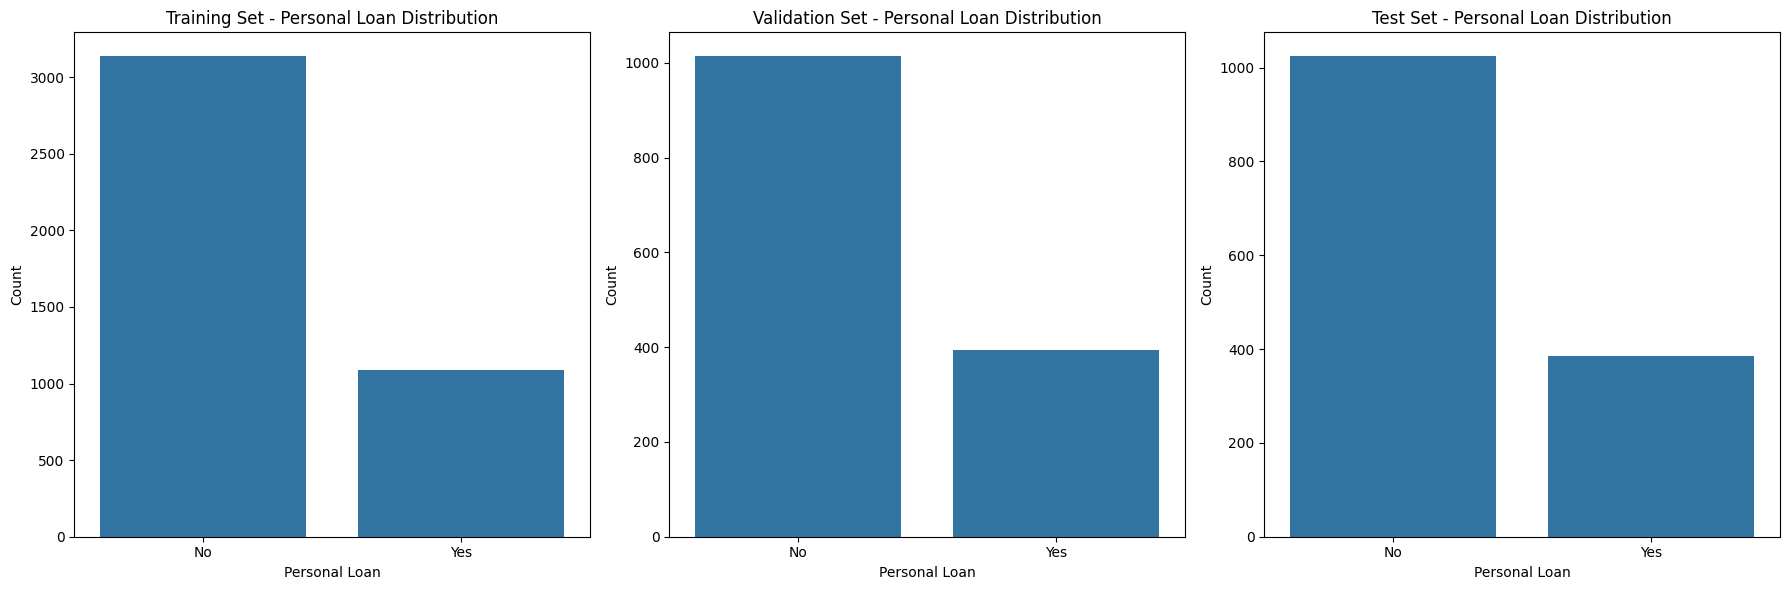

Training set Personal Loan counts and percentages:
Personal Loan
0    3136
1    1089
Name: count, dtype: int64
Personal Loan
0    74.22
1    25.78
Name: proportion, dtype: float64

Validation set Personal Loan counts and percentages:
Personal Loan
0    1014
1     395
Name: count, dtype: int64
Personal Loan
0    71.97
1    28.03
Name: proportion, dtype: float64

Test set Personal Loan counts and percentages:
Personal Loan
0    1024
1     385
Name: count, dtype: int64
Personal Loan
0    72.68
1    27.32
Name: proportion, dtype: float64


In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine the features and target for plotting
train_data = X_train.copy()
train_data['Personal Loan'] = y_train

val_data = X_val.copy()
val_data['Personal Loan'] = y_val

test_data = X_test.copy()
test_data['Personal Loan'] = y_test

# Plot the distribution of 'Personal Loan' in each partition
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

sns.countplot(data=train_data, x='Personal Loan', ax=axs[0])
axs[0].set_title('Training Set - Personal Loan Distribution')
axs[0].set_xlabel('Personal Loan')
axs[0].set_ylabel('Count')
axs[0].set_xticks([0, 1])
axs[0].set_xticklabels(['No', 'Yes'])

sns.countplot(data=val_data, x='Personal Loan', ax=axs[1])
axs[1].set_title('Validation Set - Personal Loan Distribution')
axs[1].set_xlabel('Personal Loan')
axs[1].set_ylabel('Count')
axs[1].set_xticks([0, 1])
axs[1].set_xticklabels(['No', 'Yes'])


sns.countplot(data=test_data, x='Personal Loan', ax=axs[2])
axs[2].set_title('Test Set - Personal Loan Distribution')
axs[2].set_xlabel('Personal Loan')
axs[2].set_ylabel('Count')
axs[2].set_xticks([0, 1])
axs[2].set_xticklabels(['No', 'Yes'])

plt.tight_layout()
plt.show()

# Print counts and percentages for each partition
print("Training set Personal Loan counts and percentages:")
train_counts = train_data['Personal Loan'].value_counts()
train_percentages = train_data['Personal Loan'].value_counts(normalize=True) * 100
print(train_counts)
print(train_percentages.round(2)) # Round percentages to 2 decimal places


print("\nValidation set Personal Loan counts and percentages:")
val_counts = val_data['Personal Loan'].value_counts()
val_percentages = val_data['Personal Loan'].value_counts(normalize=True) * 100
print(val_counts)
print(val_percentages.round(2)) # Round percentages to 2 decimal places


print("\nTest set Personal Loan counts and percentages:")
test_counts = test_data['Personal Loan'].value_counts()
test_percentages = test_data['Personal Loan'].value_counts(normalize=True) * 100
print(test_counts)
print(test_percentages.round(2)) # Round percentages to 2 decimal places

#Discriminant Analysis

**Prompt 3:** Build a discriminant analysis model to predict churn using all predictors.

In [49]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Initialize the LDA model
lda_model = LinearDiscriminantAnalysis()

# Train the model using the training data
lda_model.fit(X_train, y_train)

print("LDA model trained successfully.")

LDA model trained successfully.


View the coefficients for the discriminant function to understand the weights for each predictor variable in the linear discriminant function, which is a linear combination of the features, where each feature is multiplied by its corresponding coefficient and then summed up.

In [50]:
# Get the feature names from X_train
feature_names = X_train.columns

# Get the coefficients from the trained LDA model
coefficients = lda_model.coef_[0]

# Create a pandas Series to associate coefficients with feature names
coef_series = pd.Series(coefficients, index=feature_names)

# Display the coefficients with predictor names
print("Discriminant Function Coefficients:")
print(coef_series)
print("\nIntercept:", lda_model.intercept_[0])

Discriminant Function Coefficients:
Tenure Months                     -0.034215
Monthly Charges                    0.019251
Contract_One year                 -0.740352
Contract_Two year                 -0.374779
Gender_Male                       -0.019828
Senior Citizen_Yes                 0.060829
Partner_Yes                        0.237187
Dependents_Yes                    -1.037975
Multiple Lines_No phone service    0.694958
Multiple Lines_Yes                 0.295064
Internet Service_Fiber optic       0.387640
Internet Service_No               -0.404532
Online Security_Yes               -0.619213
Online Backup_Yes                 -0.346470
Device Protection_Yes             -0.193253
Tech Support_Yes                  -0.540290
Paperless Billing_Yes              0.389120
Electronic Check_Yes               0.612063
dtype: float64

Intercept: -1.5021958048460542


**Prompt 4:** Check model performance by partition with total accuracy, precision, recall, F1 score, and AUC.

Training Set Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      3136
           1       0.64      0.55      0.59      1089

    accuracy                           0.81      4225
   macro avg       0.75      0.72      0.73      4225
weighted avg       0.80      0.81      0.80      4225


Validation Set Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1014
           1       0.70      0.62      0.66       395

    accuracy                           0.82      1409
   macro avg       0.78      0.76      0.77      1409
weighted avg       0.81      0.82      0.82      1409


Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1024
           1       0.66      0.57      0.61       385

    accuracy                           0.80      1409
   macro avg       0

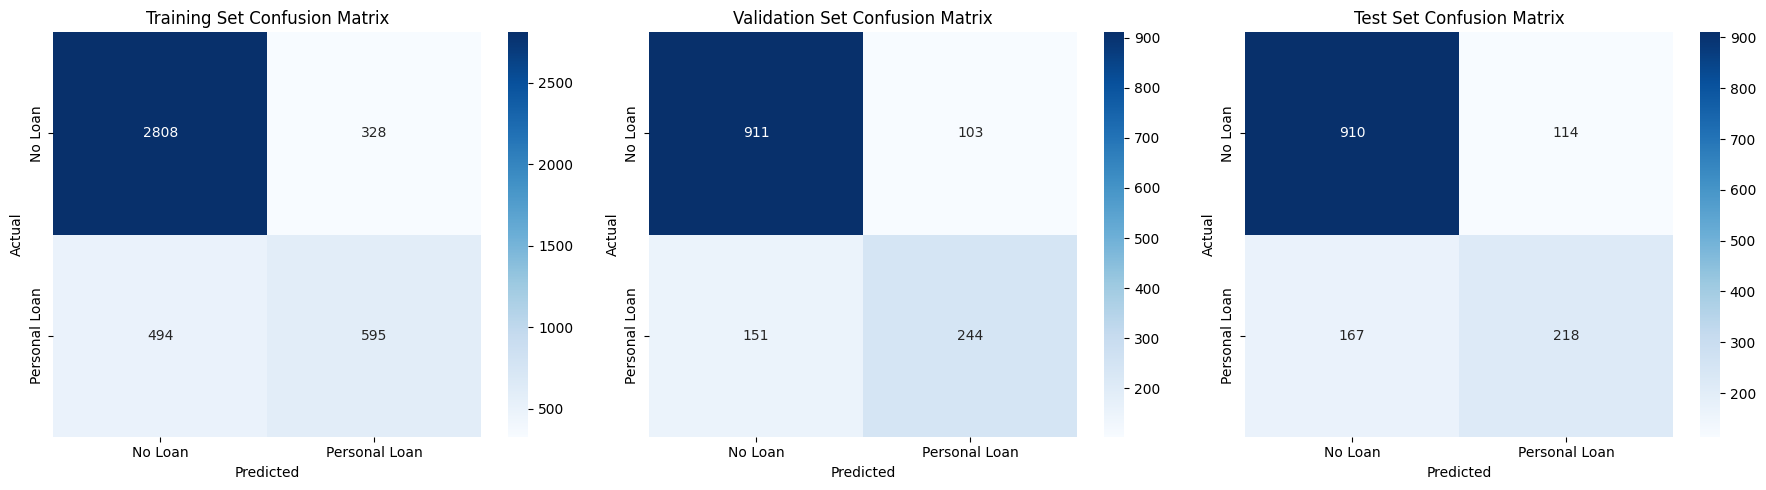

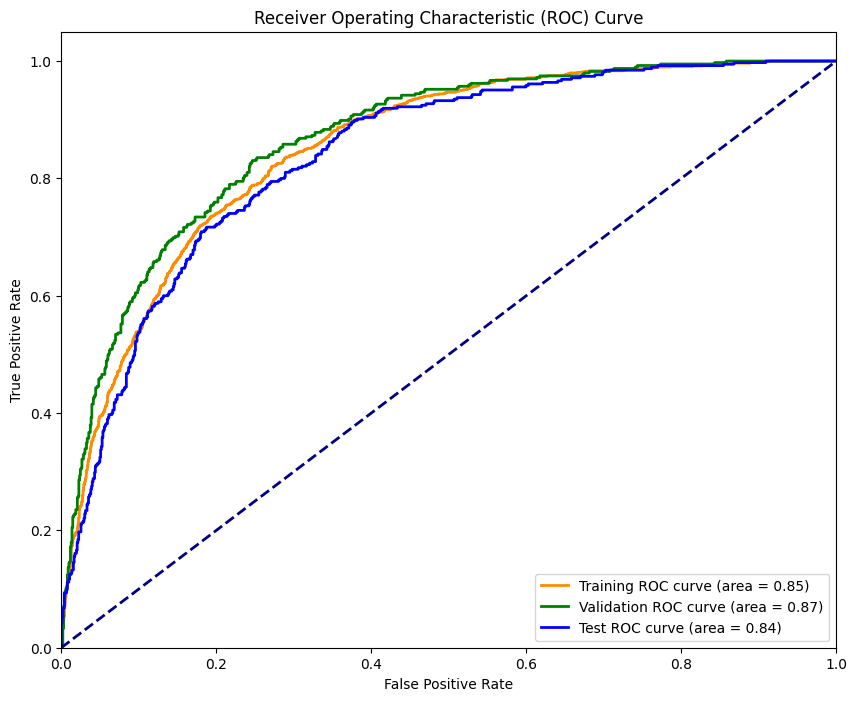

In [51]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the training, validation, and test sets
y_train_pred = lda_model.predict(X_train)
y_val_pred = lda_model.predict(X_val)
y_test_pred = lda_model.predict(X_test)

# Calculate confusion matrices
conf_matrix_train = confusion_matrix(y_train, y_train_pred)
conf_matrix_val = confusion_matrix(y_val, y_val_pred)
conf_matrix_test = confusion_matrix(y_test, y_test_pred)

# Calculate accuracy scores
accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_val = accuracy_score(y_val, y_val_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)

# Print classification reports (includes precision, recall, f1-score, and support)
print("Training Set Classification Report:")
print(classification_report(y_train, y_train_pred))

print("\nValidation Set Classification Report:")
print(classification_report(y_val, y_val_pred))

print("\nTest Set Classification Report:")
print(classification_report(y_test, y_test_pred))


# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(conf_matrix_train, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Training Set Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['No Loan', 'Personal Loan'])
axes[0].set_yticklabels(['No Loan', 'Personal Loan'])

sns.heatmap(conf_matrix_val, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Validation Set Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticklabels(['No Loan', 'Personal Loan'])
axes[1].set_yticklabels(['No Loan', 'Personal Loan'])

sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title('Test Set Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
axes[2].set_xticklabels(['No Loan', 'Personal Loan'])
axes[2].set_yticklabels(['No Loan', 'Personal Loan'])

plt.tight_layout()
plt.show()


# Calculate ROC curves and AUC
y_train_prob = lda_model.predict_proba(X_train)[:, 1]
y_val_prob = lda_model.predict_proba(X_val)[:, 1]
y_test_prob = lda_model.predict_proba(X_test)[:, 1]

fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train_prob)
roc_auc_train = auc(fpr_train, tpr_train)

fpr_val, tpr_val, thresholds_val = roc_curve(y_val, y_val_prob)
roc_auc_val = auc(fpr_val, tpr_val)

fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_prob)
roc_auc_test = auc(fpr_test, tpr_test)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2, label='Training ROC curve (area = %0.2f)' % roc_auc_train)
plt.plot(fpr_val, tpr_val, color='green', lw=2, label='Validation ROC curve (area = %0.2f)' % roc_auc_val)
plt.plot(fpr_test, tpr_test, color='blue', lw=2, label='Test ROC curve (area = %0.2f)' % roc_auc_test)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

**Prompt 5:** Comment on the model performance. What did you observe in the results?

**Answer:** In the training portion of the data, we observe the highest scores for class 0, consisting of 0.85 precision, 0.90 recall, and 0.87 f1-score. For class 1, the scores measuring precision, recall, and F1-score are all significantly lower than class 0, with values of 0.64, 0.55, and 0.59, respectively. The accuracy score is at 0.81, which is solid.

In the validation portion of the data, we observe that there were only minimal improvements in the detection of class 0; for class 1 there was a moderate increase in the scores measuring precision, recall, and f1-scores compared with the training portion's data, with values of 0.70, 0.62, and 0.66, respectively. The accuracy score improved minimally to 0.82.

In the test portion of the data, we observe minimal changes for class 0 compared to the training portion, with the precision, recall, and F-1 scores for class 1 falling down to similar levels as the training set, with 0.84, 0.57, and 0.61 recorded, respectively. The accuracy score reduced back down to 0.80, a minimal change.

These results show that between the training and test sets, minor increases in scores measuring precision, recall, and F-1 scores were achieved.

#Naive Bayes

**Prompt 6:** Build a Naïve Bayes model to predict churn using all predictors.

Build the Gaussian version of the model which doesn't require binning, as the data in this dataset is continuous.

In [52]:
from sklearn.naive_bayes import GaussianNB

# Initialize the Gaussian Naive Bayes model
gnb_model = GaussianNB()

# Train the model using the training data
gnb_model.fit(X_train, y_train)

print("Gaussian Naive Bayes model trained successfully.")

Gaussian Naive Bayes model trained successfully.


**Prompt 7:** Check model performance by partition with total accuracy, precision, recall, F1 score, and AUC.

In [53]:
from sklearn.metrics import classification_report

# Make predictions on the training, validation, and test sets
y_train_pred_gnb = gnb_model.predict(X_train)
y_val_pred_gnb = gnb_model.predict(X_val)
y_test_pred_gnb = gnb_model.predict(X_test)

# Print the classification reports
print("Training Set Classification Report (Naive Bayes):")
print(classification_report(y_train, y_train_pred_gnb))

print("\nValidation Set Classification Report (Naive Bayes):")
print(classification_report(y_val, y_val_pred_gnb))

print("\nTest Set Classification Report (Naive Bayes):")
print(classification_report(y_test, y_test_pred_gnb))

Training Set Classification Report (Naive Bayes):
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      3136
           1       0.52      0.77      0.62      1089

    accuracy                           0.76      4225
   macro avg       0.71      0.76      0.72      4225
weighted avg       0.80      0.76      0.77      4225


Validation Set Classification Report (Naive Bayes):
              precision    recall  f1-score   support

           0       0.91      0.76      0.83      1014
           1       0.57      0.80      0.66       395

    accuracy                           0.77      1409
   macro avg       0.74      0.78      0.75      1409
weighted avg       0.81      0.77      0.78      1409


Test Set Classification Report (Naive Bayes):
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1024
           1       0.53      0.77      0.63       385

    accuracy                    

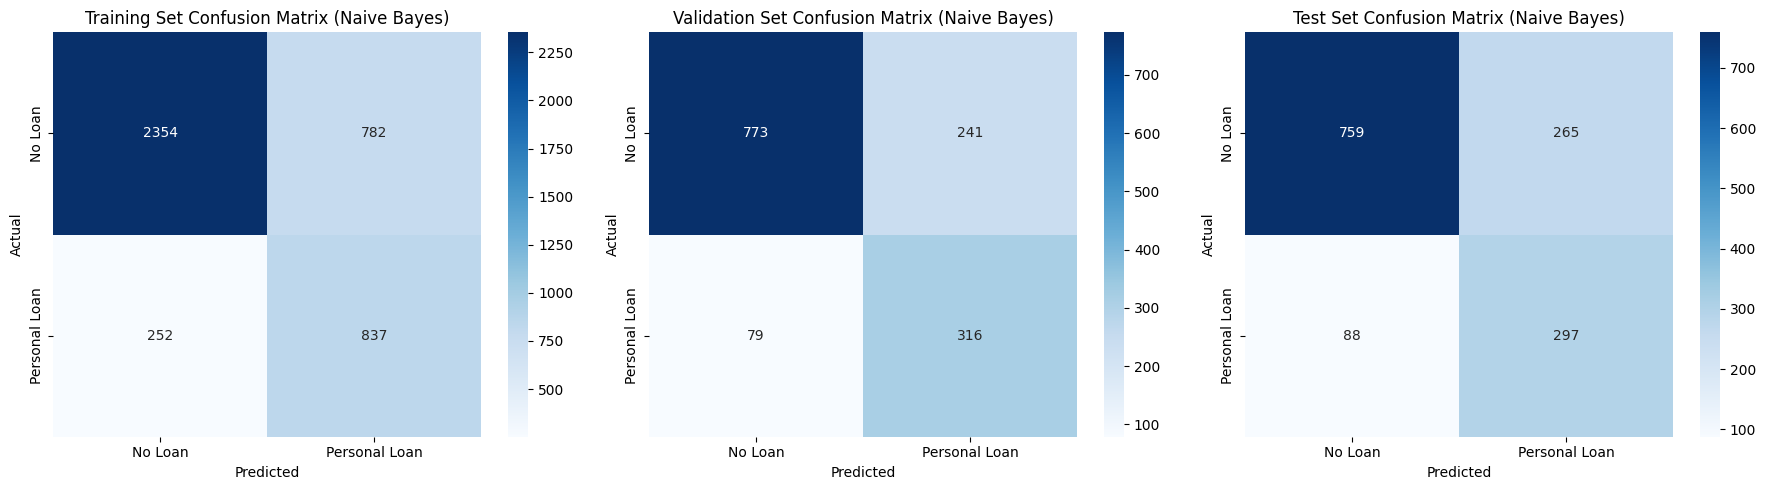

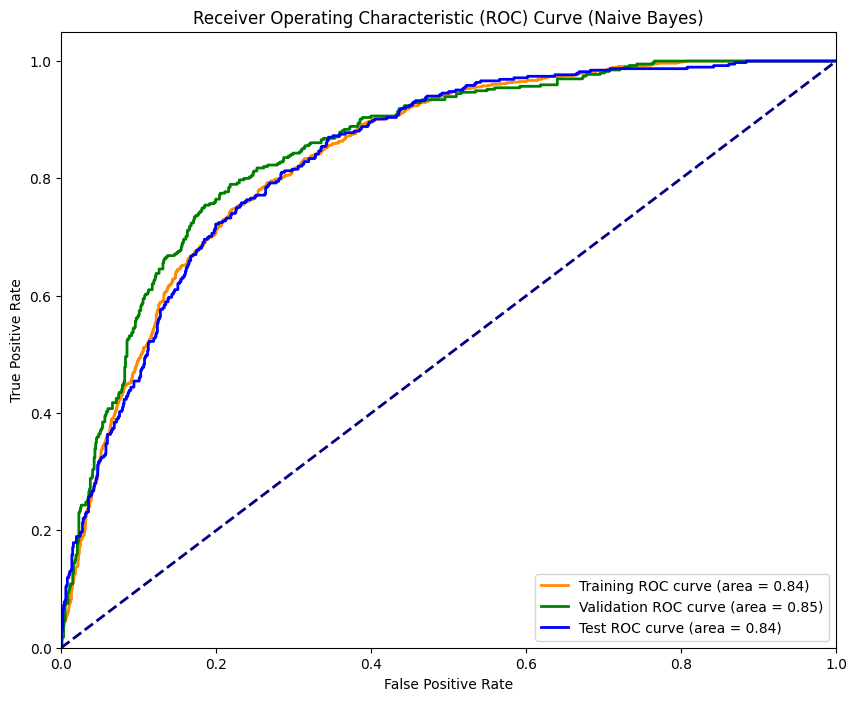

In [54]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions and get probabilities on the training, validation, and test sets
y_train_pred_gnb = gnb_model.predict(X_train)
y_val_pred_gnb = gnb_model.predict(X_val)
y_test_pred_gnb = gnb_model.predict(X_test)

y_train_prob_gnb = gnb_model.predict_proba(X_train)[:, 1]
y_val_prob_gnb = gnb_model.predict_proba(X_val)[:, 1]
y_test_prob_gnb = gnb_model.predict_proba(X_test)[:, 1]


# Calculate confusion matrices
conf_matrix_train_gnb = confusion_matrix(y_train, y_train_pred_gnb)
conf_matrix_val_gnb = confusion_matrix(y_val, y_val_pred_gnb)
conf_matrix_test_gnb = confusion_matrix(y_test, y_test_pred_gnb)

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(conf_matrix_train_gnb, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Training Set Confusion Matrix (Naive Bayes)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['No Loan', 'Personal Loan'])
axes[0].set_yticklabels(['No Loan', 'Personal Loan'])


sns.heatmap(conf_matrix_val_gnb, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Validation Set Confusion Matrix (Naive Bayes)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticklabels(['No Loan', 'Personal Loan'])
axes[1].set_yticklabels(['No Loan', 'Personal Loan'])


sns.heatmap(conf_matrix_test_gnb, annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title('Test Set Confusion Matrix (Naive Bayes)')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
axes[2].set_xticklabels(['No Loan', 'Personal Loan'])
axes[2].set_yticklabels(['No Loan', 'Personal Loan'])

plt.tight_layout()
plt.show()


# Calculate ROC curves and AUC
fpr_train_gnb, tpr_train_gnb, thresholds_train_gnb = roc_curve(y_train, y_train_prob_gnb)
roc_auc_train_gnb = auc(fpr_train_gnb, tpr_train_gnb)

fpr_val_gnb, tpr_val_gnb, thresholds_val_gnb = roc_curve(y_val, y_val_prob_gnb)
roc_auc_val_gnb = auc(fpr_val_gnb, tpr_val_gnb)

fpr_test_gnb, tpr_test_gnb, thresholds_test_gnb = roc_curve(y_test, y_test_prob_gnb)
roc_auc_test_gnb = auc(fpr_test_gnb, tpr_test_gnb)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_train_gnb, tpr_train_gnb, color='darkorange', lw=2, label='Training ROC curve (area = %0.2f)' % roc_auc_train_gnb)
plt.plot(fpr_val_gnb, tpr_val_gnb, color='green', lw=2, label='Validation ROC curve (area = %0.2f)' % roc_auc_val_gnb)
plt.plot(fpr_test_gnb, tpr_test_gnb, color='blue', lw=2, label='Test ROC curve (area = %0.2f)' % roc_auc_test_gnb)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Naive Bayes)')
plt.legend(loc="lower right")
plt.show()

**Prompt 8:** Comment on the model performance. What did you observe in the results?

**Answer:** Answer: In the training portion of the data, we observe the highest scores for class 0, consisting of 0.90 precision, 0.75 recall, and 0.82 f1-score. For class 1, the scores measuring precision, recall, and F1-score had values of 0.52, 0.77, and 0.62, respectively. The accuracy score is at 0.76, which is solid.

In the validation portion of the data, we observe that there were only minimal improvements in the detection of class 0; there was a minimal increase in the scores measuring precision, recall, and f1-scores for class 1 compared with the training portion's data, with values of 0.57, 0.80, and 0.66, respectively. The accuracy score improved minimally to 0.77.

In the test portion of the data, we observe minimal changes for class 0 compared to the training portion, with the precision, recall, and F-1 scores for class 1 falling down to similar levels as the training set, with 0.53, 0.77, and 0.63 recorded, respectively. The accuracy score reduced back down to 0.75, a moderate change.

These results show that between the training and test sets, minor increases in scores measuring precision, recall, and F-1 scores were achieved.

**Prompt 9:** Which model is better?  Justify your choice.

**Answer:** Given the available data, I find the **discriminant analysis model** to perform slightly better than the Naive Bayes model.

The discriminant analysis model yielded significantly better overall test results for Class 0 and minor improvements to the precision, recall, and F-1 score for Class 1, compared to the same categories for the Naive Bayes model.